In [1]:
from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'AD', 'OP']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [4]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化：默认选择第一个按钮
    if dataset_range_buttons:
        first_range_btn = dataset_range_buttons[0]
        set_dataset_range_boundary(first_range_btn.description)
        update_range_display()

In [5]:
tick_granularity = 0  # 颗粒度

if __name__ == '__main__':

    # 创建颗粒度组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity: ',
        layout = {'width': '200px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 颗粒度按钮
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # 输出显示区域
    display_output = widgets.Textarea(
        value = '当前颗粒度 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        tick_granularity_input,
        granularity_button_row,
        display_output
    ]))

    def update_display():
        """更新显示区域"""
        global tick_granularity
        display_output.value = f'当前颗粒度 tick_granularity: {tick_granularity}'

    def update_granularity(value):
        """更新颗粒度"""
        global tick_granularity
        tick_granularity = value
        tick_granularity_input.value = value
        update_display()

    def on_tick_granularity_input_change(change):
        """当颗粒度输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_granularity(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_granularity_button_click(btn):
        """当颗粒度按钮点击时"""
        update_granularity(btn.value)

    # 绑定事件
    tick_granularity_input.observe(on_tick_granularity_input_change, names = 'value')

    # 绑定所有颗粒度按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_granularity_button_click)

    update_display()

In [6]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')
os.makedirs(tick_granularity_resample_path, exist_ok = True) # 创建必要目录，若不存在

# 主力片段拼接分钟时间序列文件路径 main_continuous_minutely_timeseries_path
main_continuous_minutely_timeseries_path = os.path.join(dataset_range_boundary_path, f'main_continuous_minutely_timeseries.csv')
main_continuous_minutely_timeseries = pd.read_csv(main_continuous_minutely_timeseries_path, dtype = {'date': str, })

# 时间轴数据文件路径 time_axis_data_path
time_axis_data_path = os.path.join(tick_granularity_resample_path, 'time_axis_data')
os.makedirs(time_axis_data_path, exist_ok = True) # 创建必要目录，若不存在

# 交易量驱动事件轴数据文件路径 volume_axis_data_path
volume_axis_data_path = os.path.join(tick_granularity_resample_path, 'volume_axis_data')
os.makedirs(volume_axis_data_path, exist_ok = True) # 创建必要目录，若不存在

# 交易额驱动事件轴数据文件路径 money_axis_data_path
money_axis_data_path = os.path.join(tick_granularity_resample_path, 'money_axis_data')
os.makedirs(money_axis_data_path, exist_ok = True) # 创建必要目录，若不存在

### 1. 重采样方案集

In [7]:
def resample_N_rows(main_continuous_minutely_timeseries, tick_granularity):

    main_continuous_minutely_timeseries['group'] = (main_continuous_minutely_timeseries.index // tick_granularity)
    agg_rules = { # 定义聚合规则
        'date': 'last',
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum',
        'money': 'sum',
        'open_interest': 'last'
    }
    main_continuous_Nrow_timeseries = main_continuous_minutely_timeseries.groupby('group').agg(agg_rules)
    return main_continuous_Nrow_timeseries.reset_index(drop = True)

In [8]:
def resample_N_volume_03(main_continuous_minutely_timeseries, tick_granularity):
    """
    按成交量重采样为等量 K 线（允许拆分分钟线）
    假设每分钟 K 线的最高价和最低价都出现在该分钟的正中央
    开盘价到收盘价，O-H-C，O-L-C 认为是两个独立的路径
    """
    volume_threshold = main_continuous_minutely_timeseries['volume'].sum() / (len(main_continuous_minutely_timeseries) / tick_granularity)
    resampled_bars = []
    current_bar = None
    accumulated_volume = 0

    for index, row in main_continuous_minutely_timeseries.iterrows():

        if current_bar is None:  # 如果是新 K 线的开始
            current_bar = {
                'sob': row['date'], # start of Bar
                'date': row['date'], # end of Bar
                'open': row['open'],
                'high': row['high'],
                'low': row['low'],
                'close': row['close'],
                'volume': 0,
                'open_interest': 0,
                'money': 0,
            }

        remaining_volume_needed = volume_threshold - accumulated_volume # 计算当前 K 线还需要多少成交量

        # 情况 1：当前分钟线成交量小于等于剩余需求量
        if row['volume'] <= remaining_volume_needed:
            current_bar['high'] = max(current_bar['high'], row['high']) # 整根分钟线加入当前等量K线
            current_bar['low'] = min(current_bar['low'], row['low'])
            current_bar['close'] = row['close']
            current_bar['volume'] += row['volume']
            current_bar['money'] += row['money']
            current_bar['open_interest'] += row['open_interest']
            current_bar['date'] = row['date']

            accumulated_volume += row['volume']
            if accumulated_volume >= volume_threshold: # 如果达到或超过阈值，完成当前 K 线

                start_dt = pd.to_datetime(current_bar['sob'])
                end_dt = pd.to_datetime(current_bar['date'])
                current_bar['duration'] = (end_dt - start_dt).total_seconds() # 计算持续时间（秒）

                resampled_bars.append(current_bar)
                current_bar = None
                accumulated_volume = 0

        # 情况 2：当前分钟线成交量大于剩余需求量，需要拆分
        else:
            split_ratio = remaining_volume_needed / row['volume'] # 计算拆分比例
            O, H, L, C = row['open'], row['high'], row['low'], row['close'] # 获取分钟线的 OHLC

            # 假设最高价和最低价都出现在该分钟的正中央（时间比例 0.5 处）
            # 因此价格路径分为两段：
            # 第一段：从 O 到 H （或 L），时间从 0 到 0.5
            # 第二段：从 H（或 L）到 C，时间从 0.5 到 1

            # 根据拆分比例确定拆分点处于哪个时间段
            if split_ratio <= 0.5:
                # 拆分点在第一段（O 到 H/L）
                time_ratio = split_ratio / 0.5  # 映射到 0-1 范围
                # 计算高路径的拆分点价格
                high_split = O + (H - O) * time_ratio
                # 计算低路径的拆分点价格
                low_split = O + (L - O) * time_ratio

                current_bar['high'] = O + high_split * 0.5
                current_bar['low'] = O + low_split * 0.5

            else:
                current_bar['high'] = H
                current_bar['low'] = L

            # 拆分点价格为分钟开盘到分钟收盘的线性插值
            split_price = O + (C - O) * split_ratio

            # 完成当前等量 K 线（第一部分）
            current_bar['close'] = split_price
            current_bar['volume'] += remaining_volume_needed
            current_bar['money'] += row['money'] * split_ratio
            current_bar['open_interest'] += row['open_interest'] * split_ratio
            current_bar['date'] = row['date']

            start_dt = pd.to_datetime(current_bar['sob'])
            end_dt = pd.to_datetime(current_bar['date'])
            current_bar['duration'] = (end_dt - start_dt).total_seconds()
            resampled_bars.append(current_bar)

            # 开始新的等量 K 线（第二部分）
            remaining_volume = row['volume'] - remaining_volume_needed # 剩余部分的成交量

            # 对于第二部分，我们需要计算剩余部分的高点和低点
            # 剩余部分从 split_price 开始，到 C 结束
            # 剩余部分的高点和低点需要根据剩余部分的路径计算

            # 计算剩余部分的拆分比例
            remaining_ratio = 1 - split_ratio

            if split_ratio <= 0.5:
                # 原拆分点在第一段，剩余部分包括：
                # 1. 从拆分点到 H/L（如果拆分点在第一段）
                # 2. 从 H/L 到 C

                # 剩余部分的高点：当 split_ratio
                # 由于剩余部分包含从拆分点到 H，所以 H 肯定包含在内
                remaining_high = H

                # 剩余部分的低点：可能出现在L或C
                remaining_low = L

                # 剩余部分的开盘价：split_price
                # 剩余部分的收盘价：C
            else:
                # 原拆分点在第二段，剩余部分只包括从拆分点到 C
                # 拆分点在第二段 H 到 C
                time_ratio = remaining_ratio / 0.5 # 将剩余比例标准化到 0~1
                # 计算高路径的拆分点价格
                high_split = H + (C - H) * time_ratio
                # 计算低路径的拆分点价格
                low_split = L + (C - L) * time_ratio

                remaining_high = C + high_split * 0.5
                remaining_low = C + low_split * 0.5

            # 新 K 线从拆分点开始
            new_bar = {
                'sob': row['date'],  # 注意：实际拆分点可能在分钟内，但时间戳仍用分钟线的时间 start of Bar
                'date': row['date'], # end od Bar
                'open': split_price,
                'high': remaining_high,
                'low': remaining_low,
                'close': C,  # 临时值，会被后续更新
                'volume': remaining_volume,
                'money': row['money'] * (1 - split_ratio),
                'open_interest': row['open_interest'] * (1 - split_ratio),
            }

            current_bar = new_bar
            accumulated_volume = remaining_volume


    # 处理最后一根未完成的 K 线
    if current_bar is not None and current_bar['volume'] > 0:
        start_dt = pd.to_datetime(current_bar['sob'])
        end_dt = pd.to_datetime(current_bar['date'])
        current_bar['duration'] = (end_dt - start_dt).total_seconds()
        resampled_bars.append(current_bar)

    # 转换 resampled_bars 为 DataFrame 作为最终输出
    main_continuous_volume_timeseries = pd.DataFrame(resampled_bars)
    main_continuous_volume_timeseries = main_continuous_volume_timeseries[['date', 'open', 'high', 'low', 'close', 'volume', 'money', 'open_interest', 'duration']]
    return main_continuous_volume_timeseries

In [9]:
def resample_N_money_03(main_continuous_minutely_timeseries, tick_granularity):
    """
    按成交额重采样为等量 K 线（允许拆分分钟线）
    假设每分钟 K 线的最高价和最低价都出现在该分钟的正中央
    开盘价到收盘价，O-H-C，O-L-C 认为是三个独立的
    """
    money_threshold = main_continuous_minutely_timeseries['money'].sum() / (len(main_continuous_minutely_timeseries) / tick_granularity)
    resampled_bars = []
    current_bar = None
    accumulated_money = 0

    for index, row in main_continuous_minutely_timeseries.iterrows():

        if current_bar is None:  # 如果是新 K 线的开始
            current_bar = {
                'sob': row['date'], # start of Bar
                'date': row['date'], # end of Bar
                'open': row['open'],
                'high': row['high'],
                'low': row['low'],
                'close': row['close'],
                'volume': 0,
                'open_interest': 0,
                'money': 0,
            }

        remaining_money_needed = money_threshold - accumulated_money # 计算当前 K 线还需要多少成交额

        # 情况 1：当前分钟线成交额小于等于剩余需求量
        if row['money'] <= remaining_money_needed:
            current_bar['high'] = max(current_bar['high'], row['high']) # 整根分钟线加入当前等量 K 线
            current_bar['low'] = min(current_bar['low'], row['low'])
            current_bar['close'] = row['close']
            current_bar['volume'] += row['volume']
            current_bar['money'] += row['money']
            current_bar['open_interest'] += row['open_interest']
            current_bar['date'] = row['date']

            accumulated_money += row['money']
            if accumulated_money >= money_threshold: # 如果达到或超过阈值，完成当前 K 线

                start_dt = pd.to_datetime(current_bar['sob'])
                end_dt = pd.to_datetime(current_bar['date'])
                current_bar['duration'] = (end_dt - start_dt).total_seconds() # 计算持续时间（秒）

                resampled_bars.append(current_bar)
                current_bar = None
                accumulated_money = 0

        # 情况 2：当前分钟线成交量大于剩余需求量，需要拆分
        else:
            split_ratio = remaining_money_needed / row['money'] # 计算拆分比例
            O, H, L, C = row['open'], row['high'], row['low'], row['close'] # 获取分钟线的 OHLC

            # 假设最高价和最低价都出现在该分钟的正中央（时间比例 0.5 处）
            # 因此价格路径分为两段：
            # 第一段：从 O 到 H （或 L），时间从 0 到 0.5
            # 第二段：从 H（或 L）到 C，时间从 0.5 到 1

            # 根据拆分比例确定拆分点处于哪个时间段
            if split_ratio <= 0.5:
                # 拆分点在第一段（O 到 H/L）
                time_ratio = split_ratio / 0.5  # 映射到 0-1 范围
                # 计算高路径的拆分点价格
                high_split = O + (H - O) * time_ratio
                # 计算低路径的拆分点价格
                low_split = O + (L - O) * time_ratio

                current_bar['high'] = O + high_split * 0.5
                current_bar['low'] = O + low_split * 0.5

            else:
                current_bar['high'] = H
                current_bar['low'] = L

            # 拆分点价格为分钟开盘到分钟收盘的线性插值
            split_price = O + (C - O) * split_ratio

            # 完成当前等量 K 线（第一部分）
            current_bar['close'] = split_price
            current_bar['volume'] += row['volume'] * split_ratio
            current_bar['money'] += remaining_money_needed
            current_bar['open_interest'] += row['open_interest'] * split_ratio
            current_bar['date'] = row['date']

            start_dt = pd.to_datetime(current_bar['sob'])
            end_dt = pd.to_datetime(current_bar['date'])
            current_bar['duration'] = (end_dt - start_dt).total_seconds()
            resampled_bars.append(current_bar)

            # 开始新的等量 K 线（第二部分）
            remaining_money = row['money'] - remaining_money_needed # 剩余部分的成交量

            # 对于第二部分，我们需要计算剩余部分的高点和低点
            # 剩余部分从 split_price 开始，到 C 结束
            # 剩余部分的高点和低点需要根据剩余部分的路径计算

            # 计算剩余部分的拆分比例
            remaining_ratio = 1 - split_ratio

            if split_ratio <= 0.5:
                # 原拆分点在第一段，剩余部分包括：
                # 1. 从拆分点到 H/L（如果拆分点在第一段）
                # 2. 从 H/L 到 C

                # 剩余部分的高点：当 split_ratio
                # 由于剩余部分包含从拆分点到 H，所以 H 肯定包含在内
                remaining_high = H

                # 剩余部分的低点：可能出现在L或C
                remaining_low = L

                # 剩余部分的开盘价：split_price
                # 剩余部分的收盘价：C
            else:
                # 原拆分点在第二段，剩余部分只包括从拆分点到 C
                # 拆分点在第二段 H 到 C
                time_ratio = remaining_ratio / 0.5 # 将剩余比例标准化到 0~1
                # 计算高路径的拆分点价格
                high_split = H + (C - H) * time_ratio
                # 计算低路径的拆分点价格
                low_split = L + (C - L) * time_ratio

                remaining_high = high_split
                remaining_low = low_split

            # 新 K 线从拆分点开始
            new_bar = {
                'sob': row['date'], # 注意：实际拆分点可能在分钟内，但 start of Bar 时间戳仍用分钟线的时间
                'date': row['date'], # end od Bar
                'open': split_price,
                'high': remaining_high,
                'low': remaining_low,
                'close': C,  # 临时值，会被后续更新
                'volume': row['volume'] * (1 - split_ratio),
                'money': remaining_money,
                'open_interest': row['open_interest'] * (1 - split_ratio),
            }

            current_bar = new_bar
            accumulated_money = remaining_money


    # 处理最后一根未完成的 K 线
    if current_bar is not None and current_bar['money'] > 0:
        start_dt = pd.to_datetime(current_bar['sob'])
        end_dt = pd.to_datetime(current_bar['date'])
        current_bar['duration'] = (end_dt - start_dt).total_seconds()
        resampled_bars.append(current_bar)

    # 转换 resampled_bars 为 DataFrame 作为最终输出
    main_continuous_money_timeseries = pd.DataFrame(resampled_bars)
    main_continuous_money_timeseries = main_continuous_money_timeseries[['date', 'open', 'high', 'low', 'close', 'volume', 'money', 'open_interest', 'duration']]
    return main_continuous_money_timeseries

In [10]:
def plot_distribution_with_normal(
    series, bins_count = 1000, figsize = (25, 3), dpi = 120, xlim = None, ylim = None, fit_genhyperbolic = False, title = None
):

    diff_series = series.diff().dropna()

    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize = figsize, dpi = dpi)
    n, bins, patches = ax.hist(
        diff_series,
        bins = bins_count,
        density = True,
        color = 'white',
        edgecolor = 'black',
        linewidth = 0.25,
        label = f'采样颗粒度 {tick_granularity}'
    )

    if fit_genhyperbolic: # 计算并绘制广义双曲分布曲线

        from scipy.stats import genhyperbolic
        params = genhyperbolic.fit(diff_series)  # 用广义双曲分布拟合收益率
        p, a, b, loc, scale = params  # params 包含5个参数: p, a, b, loc, scale (对应: λ, α, β, μ, δ)
        print(
            f'形状参数 λ:{p:.4f}  '
            f'尾部参数 α:{a:.4f}  '
            f'偏度参数 β:{b:.4f}  '
            f'位置参数 μ:{loc:.4f}  '
            f'尺度参数 δ:{scale:.4f}'
        )

        x = np.linspace(diff_series.min(), diff_series.max(), 1000)
        y = genhyperbolic.pdf(x, * params)
        ax.plot(x, y, 'b', linewidth = 0.85, label = f'λ:{p:.3f}, α:{a:.3f}, β:{b:.3f}, μ:{loc:.3f}, δ:{scale:.3f}')

    if xlim is None: ax.set_xlim(diff_series.min(), diff_series.max())
    else: ax.set_xlim(xlim[0], xlim[1])

    if ylim is None: pass
    else: ax.set_ylim(ylim[0], ylim[1])

    ax.legend(loc = 'upper left')
    plt.grid(False)
    plt.title(title)
    plt.show()

In [11]:
def plot_academic_timeseries(figsize, n_ticks, index_range, values, dates, ylabel, title = None, linewidth = None):

    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    fig, ax = plt.subplots(figsize = figsize)
    ax.plot(index_range, values, linewidth = linewidth)  # 学术图通常单色

    # x 轴刻度，等距稀疏采样
    tick_positions = np.linspace(0, len(index_range) - 1, n_ticks, dtype = int)
    tick_labels = [str(dates.iloc[pos])[:10] for pos in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation = 0, ha = 'center')
    ax.set_xlim(index_range[0], index_range[-1]) # 去除前后空余

    ax.set_ylabel(ylabel, fontsize = 12)
    if title:
        ax.set_title(title, fontsize = 12, pad = 10)

    plt.show()

In [12]:
import gc; gc.collect()

16

### 2. 重采样执行与可视化

In [13]:
main_continuous_Nrow_timeseries = resample_N_rows(main_continuous_minutely_timeseries, tick_granularity)  # N 个分钟 K 线聚合

main_continuous_volume_03_timeseries = resample_N_volume_03(main_continuous_minutely_timeseries, tick_granularity)
main_continuous_volume_timeseries = main_continuous_volume_03_timeseries

main_continuous_money_03_timeseries = resample_N_money_03(main_continuous_minutely_timeseries, tick_granularity)
main_continuous_money_timeseries = main_continuous_money_03_timeseries

display(main_continuous_money_timeseries.head())
display(main_continuous_money_timeseries.tail())
import gc; gc.collect()

,date,open,high,low,close,volume,money,open_interest,duration
0,2015-01-05 09:02:00,2550.000000,2559.997947,2554.997947,2556.433014,188258.770069,4.810814e+09,4.341573e+06,60.0
1,2015-01-05 09:07:00,2556.433014,3841.919381,3841.372058,2561.316076,187925.523778,4.810814e+09,1.114960e+07,300.0
2,2015-01-05 09:13:00,2561.316076,3853.463046,3852.800338,2568.478333,187443.916410,4.810814e+09,1.552914e+07,360.0
3,2015-01-05 09:28:00,2568.478333,3843.261067,3842.572638,2561.600354,187540.263374,4.810814e+09,3.915616e+07,900.0
4,2015-01-05 09:41:00,2561.600354,3844.773762,3843.979875,2562.520935,187845.986322,4.810814e+09,3.388617e+07,780.0


,date,open,high,low,close,volume,money,open_interest,duration
64145,2026-03-31 09:01:00,3139.000000,3144.0,3141.000000,3142.413584,152651.406247,4.810814e+09,1.887070e+08,69900.0
64146,2026-03-31 09:47:00,3142.413584,3132.0,3129.000000,3130.741446,152985.104198,4.810814e+09,1.021029e+08,2760.0
64147,2026-03-31 11:17:00,3130.741446,3127.0,3125.000000,3125.366197,153149.099416,4.810814e+09,1.649846e+08,5400.0
64148,2026-03-31 13:48:00,3125.366197,3119.0,3117.000000,3117.898998,153657.894271,4.810814e+09,6.856759e+07,9060.0
64149,2026-03-31 15:00:00,3117.898998,3123.0,3117.202003,3121.000000,153627.317151,4.810814e+09,1.585615e+08,4320.0


0

形状参数 λ:-0.7766  尾部参数 α:0.4636  偏度参数 β:0.0064  位置参数 μ:-0.0001  尺度参数 δ:0.0074


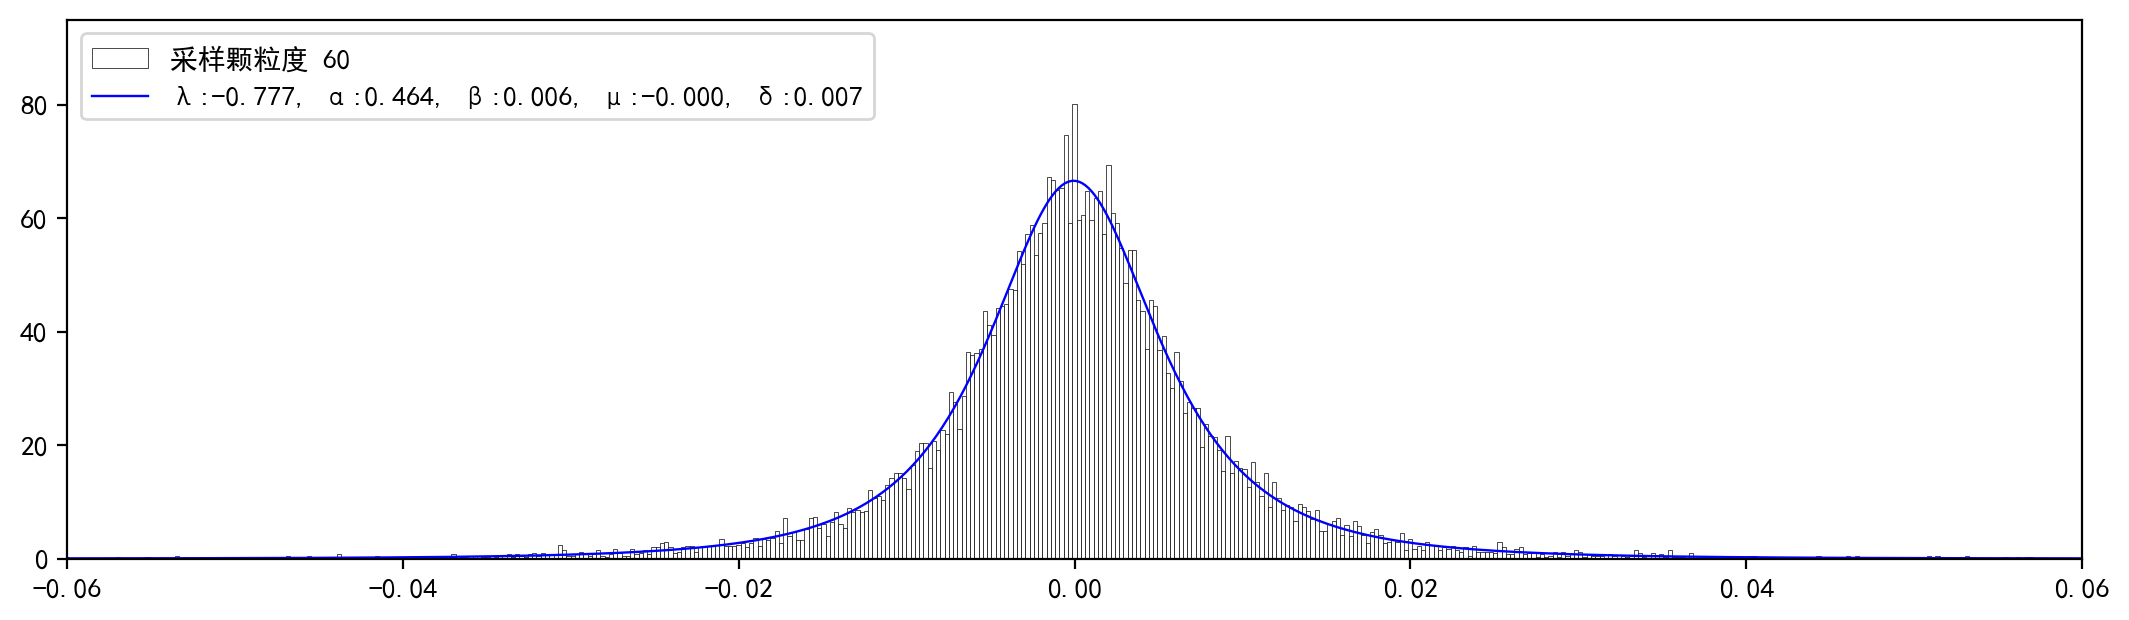

形状参数 λ:-2.8232  尾部参数 α:0.0332  偏度参数 β:0.0332  位置参数 μ:-0.0001  尺度参数 δ:0.0164


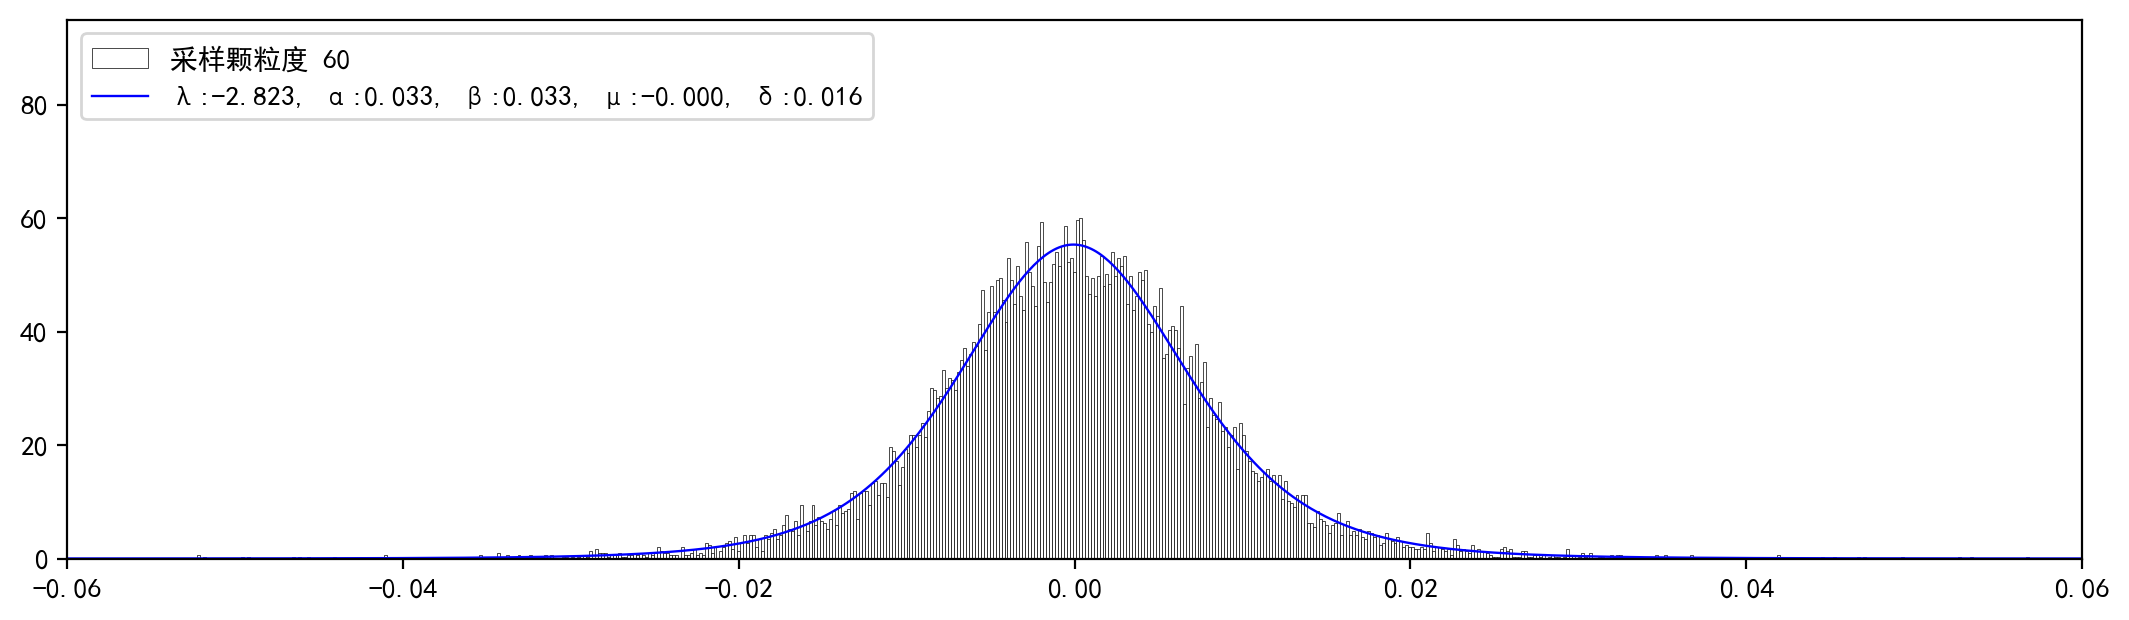

形状参数 λ:-3.0368  尾部参数 α:0.0173  偏度参数 β:0.0173  位置参数 μ:-0.0001  尺度参数 δ:0.0174


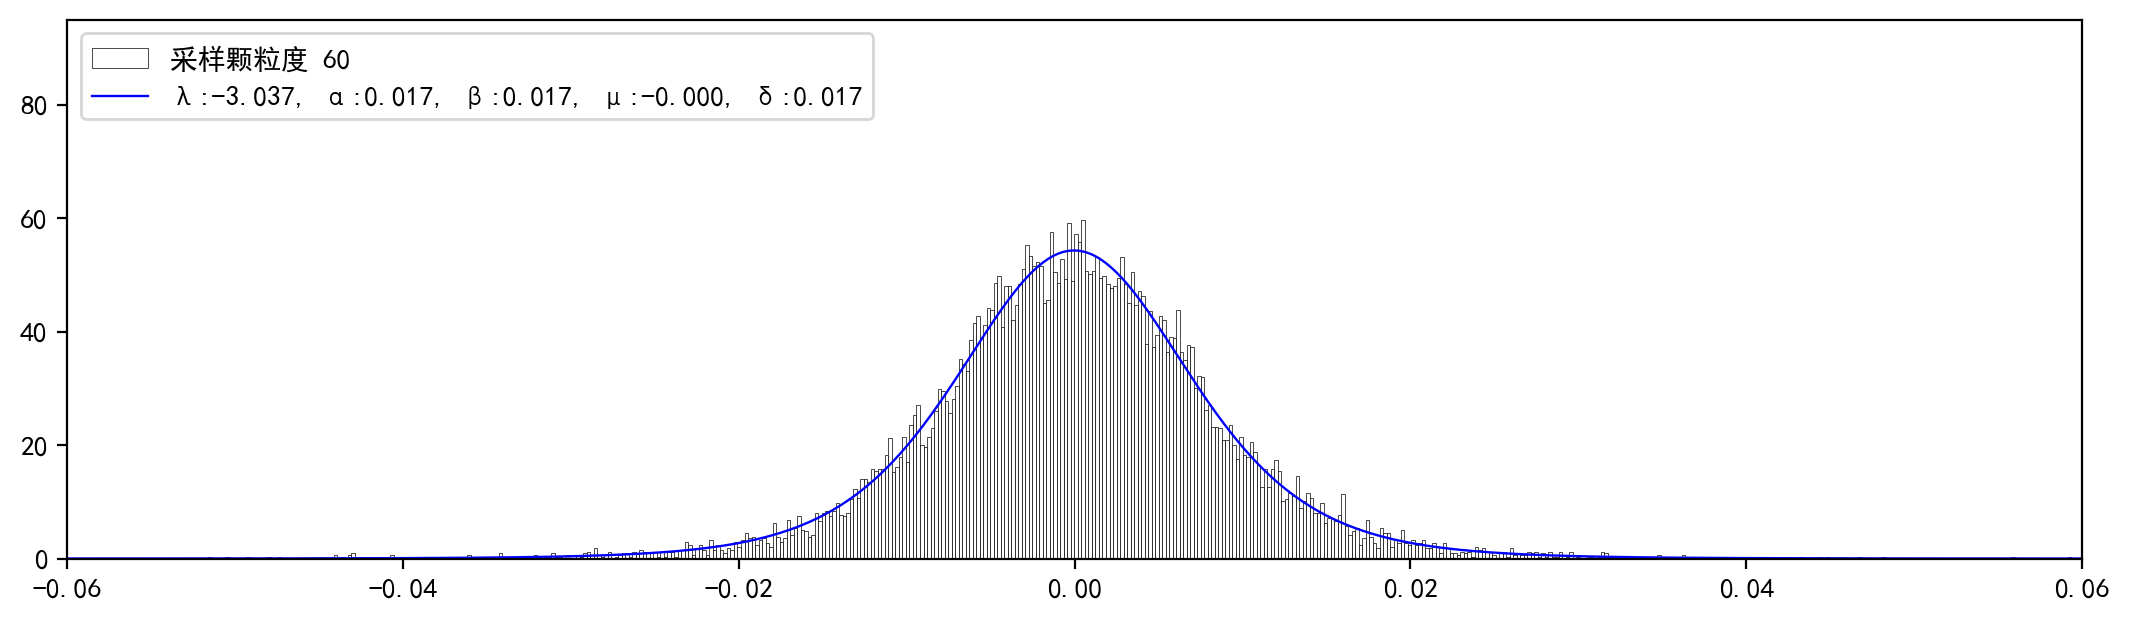

135548

In [19]:
bins_count = 700  # 分箱数
xlim_list = [-0.06, 0.06]
ylim_list = [0, 95]
figsize = (13, 3.5)
dpi = 300

fit_genhyperbolic_bool = True   # 是否进行广义双曲拟合 bool

# 尾部参数（α）：控制分布尾部的厚度。α 值越小，尾部越重，极端事件出现的概率越高；在稳定分布中，α ∈ (0,2]，通常 α < 2 表示重尾。
# 偏度参数（β）：控制分布的偏度。β = 0 时分布对称；β > 0 表示右偏（正偏），β < 0 表示左偏（负偏）。
# 位置参数（μ）：类似均值，表示分布的中心位置。
# 尺度参数（δ）：类似标准差，表示分布的离散程度或波动性；δ 值越大，数据越扩散。
# 形状参数（λ）：可能影响分布的整体形态（如峰度或形状），具体含义取决于参数化方式；λ 为负值时，分布可能更尖锐或具有更重的尾部。


Nrow_diff_series = np.log(main_continuous_Nrow_timeseries['close']).diff().dropna() # 计算差分并去空值
plot_distribution_with_normal(
    Nrow_diff_series,
    bins_count = bins_count,
    figsize = figsize,
    dpi = 200,
    xlim = xlim_list,
    ylim = ylim_list,
    fit_genhyperbolic = fit_genhyperbolic_bool,
    # title = '时间轴分钟重采样 main_continuous_Nrow_timeseries',
)


volume_diff_series = np.log(main_continuous_volume_timeseries['close']).diff().dropna() # 计算差分并去空值
plot_distribution_with_normal(
    volume_diff_series,
    bins_count = int(bins_count * 1.2),
    figsize = figsize,
    dpi = 200,
    xlim= xlim_list,
    ylim = ylim_list,
    fit_genhyperbolic = fit_genhyperbolic_bool,
    # title = '交易量驱动事件轴 main_continuous_volume_timeseries',
)


money_diff_series = np.log(main_continuous_money_timeseries['close']).diff().dropna() # 计算差分并去空值
plot_distribution_with_normal(
    money_diff_series,
    bins_count = int(bins_count * 1),
    figsize = figsize,
    dpi = 200,
    xlim= xlim_list,
    ylim = ylim_list,
    fit_genhyperbolic = fit_genhyperbolic_bool,
    # title = '交易额驱动事件轴 main_continuous_money_timeseries',
)

import gc; gc.collect()

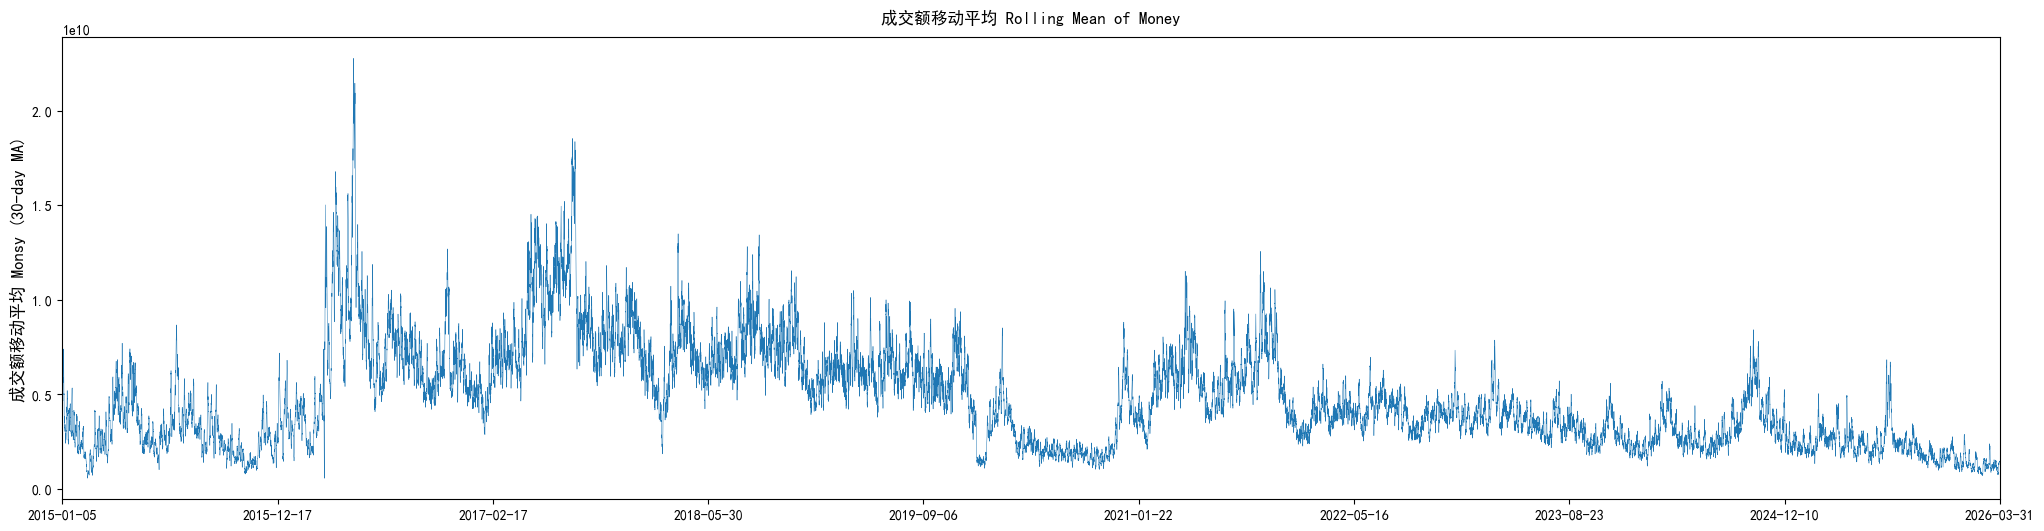

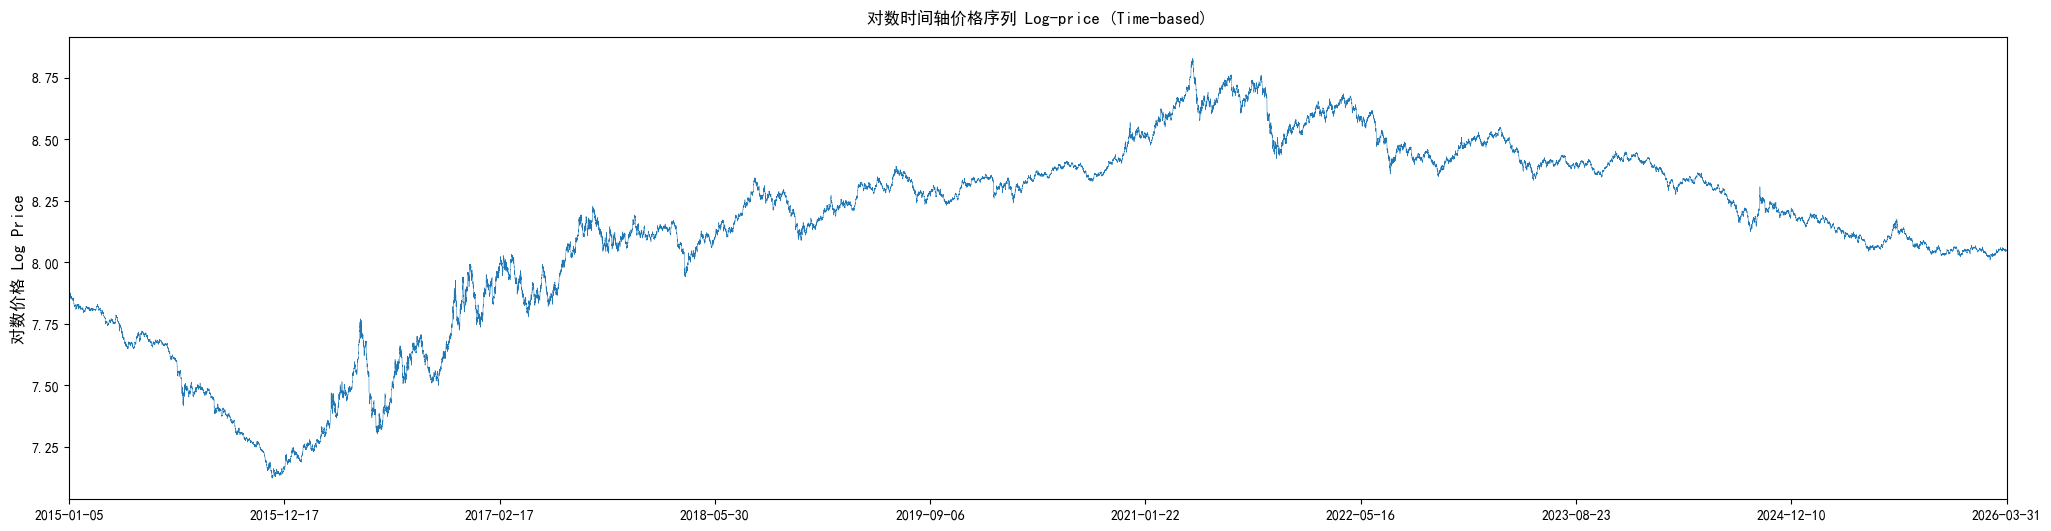

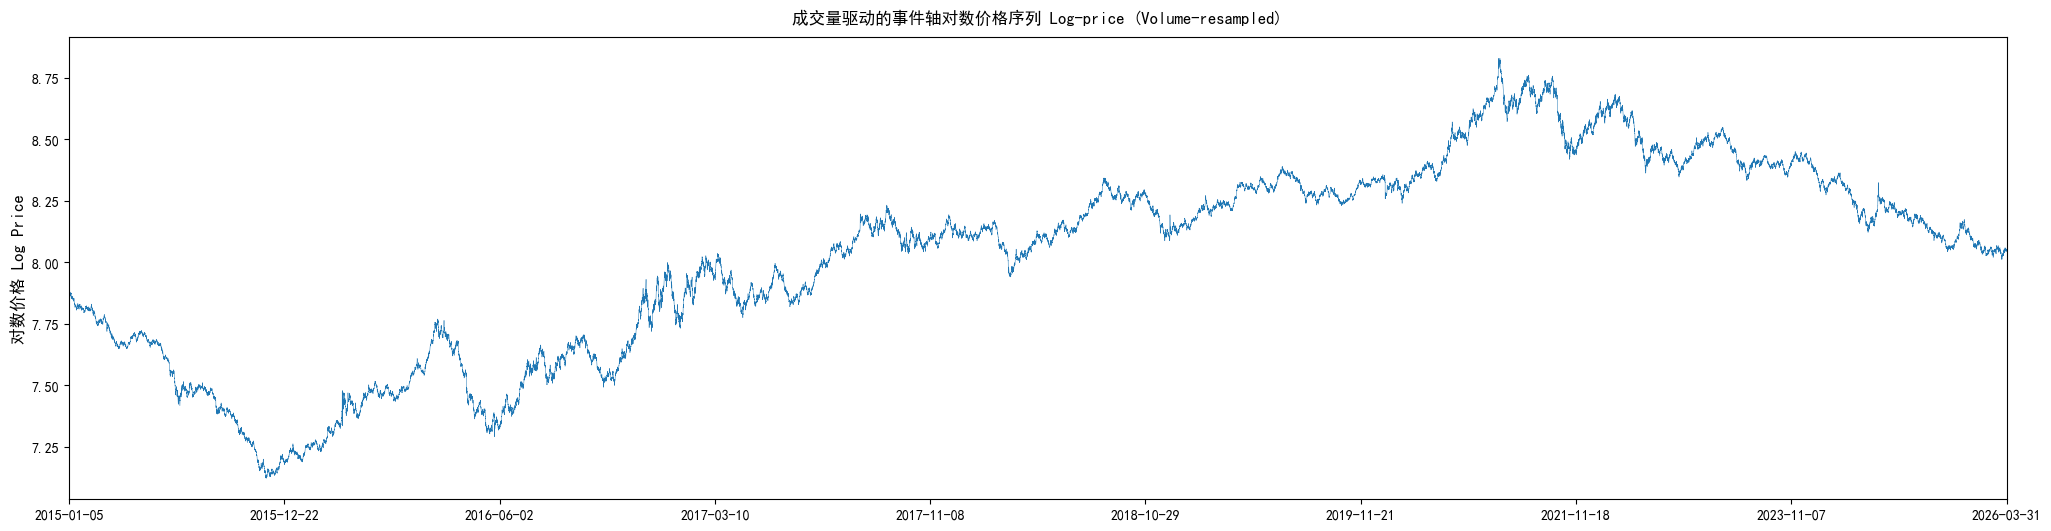

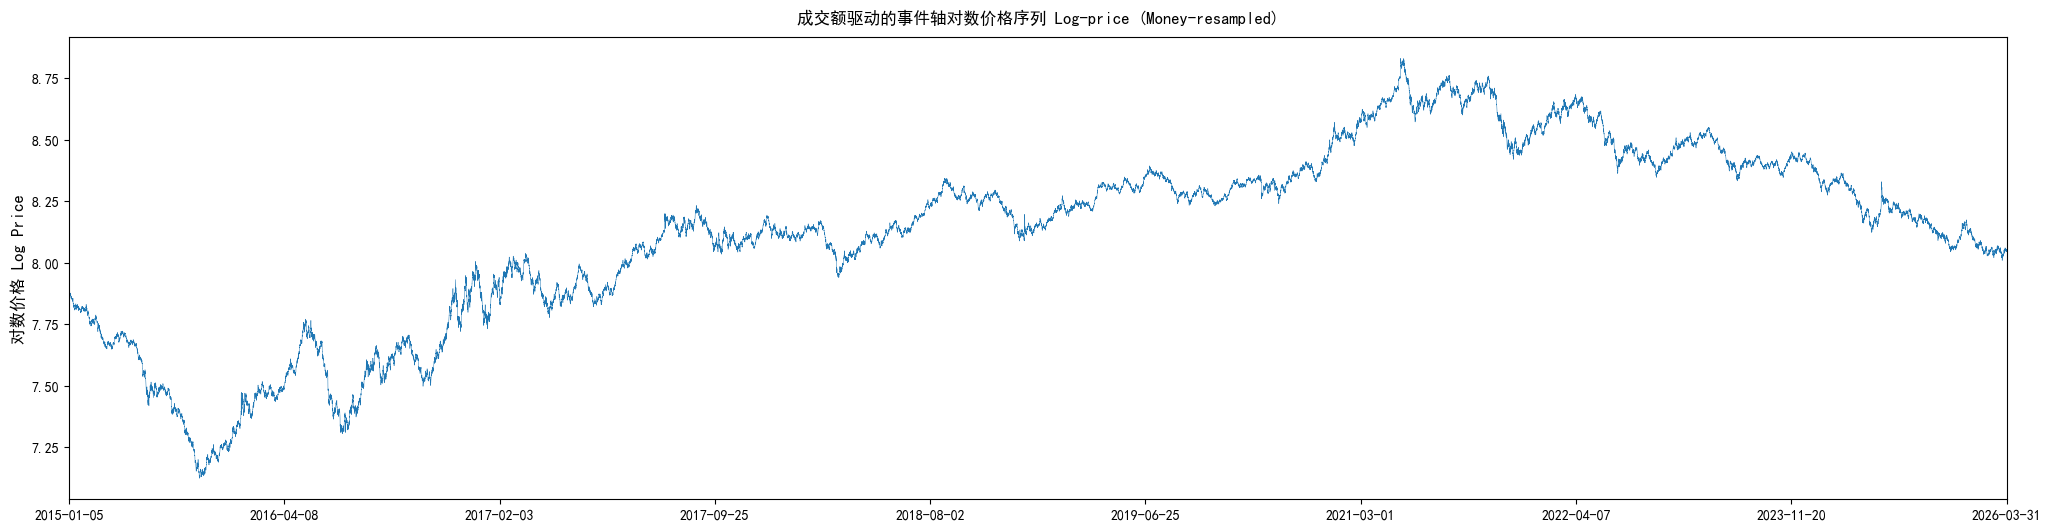

14726

In [15]:
figsize = (25, 6)
n_ticks = 10

# main_continuous_Nrow_timeseries 时间轴成交额
plot_academic_timeseries(
    figsize = figsize,
    n_ticks = n_ticks,
    index_range = range(len(main_continuous_Nrow_timeseries)),
    values = main_continuous_Nrow_timeseries['money'].rolling(30, center = True).mean(),
    dates = main_continuous_Nrow_timeseries['date'],
    ylabel = '成交额移动平均 Monsy (30-day MA)',
    title = '成交额移动平均 Rolling Mean of Money',
    linewidth = 0.35
)

# main_continuous_Nrow_timeseries 时间轴价格序列
plot_academic_timeseries(
    figsize = figsize,
    n_ticks = n_ticks,
    index_range = range(len(main_continuous_Nrow_timeseries)),
    values = np.log(main_continuous_Nrow_timeseries['close']),
    dates = main_continuous_Nrow_timeseries['date'],
    ylabel = '对数价格 Log Price',
    title = '对数时间轴价格序列 Log-price (Time-based)',
    linewidth = 0.35
)

# main_continuous_volume_timeseries 成交量驱动的事件轴价格序列
plot_academic_timeseries(
    figsize = figsize,
    n_ticks = n_ticks,
    index_range = range(len(main_continuous_volume_timeseries)),
    values = np.log(main_continuous_volume_timeseries['close']),
    dates = main_continuous_volume_timeseries['date'],
    ylabel = '对数价格 Log Price',
    title = '成交量驱动的事件轴对数价格序列 Log-price (Volume-resampled)',
    linewidth = 0.35
)

# main_continuous_money_timeseries 成交额驱动的事件轴价格序列
plot_academic_timeseries(
    figsize = figsize,
    n_ticks = n_ticks,
    index_range = range(len(main_continuous_money_timeseries)),
    values = np.log(main_continuous_money_timeseries['close']),
    dates = main_continuous_money_timeseries['date'],
    ylabel = '对数价格 Log Price',
    title = '成交额驱动的事件轴对数价格序列 Log-price (Money-resampled)',
    linewidth = 0.35
)

import gc; gc.collect()

In [29]:
def scatter_time_point_distribution(
    main_continuous_volume_timeseries_column,
    title = ''
):
    date_series = pd.to_datetime(main_continuous_volume_timeseries_column)
    plt.figure(figsize = (21, 1.8))
    plt.scatter(
        date_series,
        np.zeros(len(date_series)),
        s = 0.1195,
        alpha = 0.008,
        color = 'blue',
        marker = 'o',
        label = f'时间点分布',
    )
    plt.legend(loc = 'upper left', fontsize = 8.5)

    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))  # 自动格式化  x轴日期刻度
    plt.gcf().autofmt_xdate(rotation = 0)  # 自动调整日期标签避免重叠
    plt.tick_params(axis = 'x', labelsize = 8)

    plt.title(str(title) + f'（起始时间：{date_series.iloc[0]}）', loc = 'left', fontsize = 8.5)
    plt.yticks([])
    plt.grid(True, alpha = 0.2, linestyle = '--')
    plt.show()



# scatter_time_point_distribution(main_continuous_Nrow_timeseries['date'], title = '时间轴重采样 K 线时间点分布')
# scatter_time_point_distribution(main_continuous_volume_timeseries['date'], title = '成交量驱动事件轴 K 线时间点分布')
# scatter_time_point_distribution(main_continuous_money_timeseries['date'], title = '成交额驱动事件轴 K 线时间点分布')

In [30]:
# 时间轴数据文件路径 time_axis_data_path
time_axis_data_path = os.path.join(tick_granularity_resample_path, 'time_axis_data')

# 主力片段拼接 N 行重采样序列文件路径 main_continuous_Nrow_timeseries_path
main_continuous_Nrow_timeseries_path = os.path.join(time_axis_data_path, f'main_continuous_Nrow_timeseries.csv')
main_continuous_Nrow_timeseries.to_csv(main_continuous_Nrow_timeseries_path, index = False)

# 主力片段拼接 N 行重采样时间索引路径 main_continuous_Nrow_date_index
main_continuous_Nrow_date_index_path = os.path.join(time_axis_data_path, f'main_continuous_Nrow_date_index.csv')
main_continuous_Nrow_timeseries[['date']].to_csv(main_continuous_Nrow_date_index_path, index = False)

In [31]:
# 交易量驱动事件轴数据文件路径 volume_axis_data_path
volume_axis_data_path = os.path.join(tick_granularity_resample_path, 'volume_axis_data')

# 主力片段拼接成交量重采样序列文件路径 main_continuous_volume_timeseries_path
main_continuous_volume_timeseries_path = os.path.join(volume_axis_data_path, f'main_continuous_volume_timeseries.csv')
main_continuous_volume_timeseries.to_csv(main_continuous_volume_timeseries_path, index = False)

# 主力片段拼接成交量重采样时间索引路径 main_continuous_volume_date_index
main_continuous_volume_date_index_path = os.path.join(volume_axis_data_path, f'main_continuous_volume_date_index.csv')
main_continuous_volume_timeseries[['date']].to_csv(main_continuous_volume_date_index_path, index = False)

In [32]:
# 交易额驱动事件轴数据文件路径 money_axis_data_path
money_axis_data_path = os.path.join(tick_granularity_resample_path, 'money_axis_data')

# 主力片段拼接成交额重采样序列文件路径 main_continuous_money_timeseries_path
main_continuous_money_timeseries_path = os.path.join(money_axis_data_path, f'main_continuous_money_timeseries.csv')
main_continuous_money_timeseries.to_csv(main_continuous_money_timeseries_path, index = False)

# 主力片段拼接成交额重采样时间索引路径 main_continuous_money_date_index
main_continuous_money_date_index_path = os.path.join(money_axis_data_path, f'main_continuous_money_date_index.csv')
main_continuous_money_timeseries[['date']].to_csv(main_continuous_money_date_index_path, index = False)